# Deep Convolutional GAN for MNIST Digit Generation

## Problem Statement

The goal of this notebook is to build a Deep Convolutional Generative Adversarial Network (DCGAN) that learns to generate handwritten digit images similar to those in the MNIST dataset.

A Vanilla GAN usually uses fully connected dense layers. A DCGAN improves image generation by using convolutional neural network layers, which are better suited for learning spatial image patterns.

In this problem, the Generator creates 28x28 grayscale digit images from random noise, while the Discriminator uses convolutional layers to classify images as real or generated.

## Objectives

By the end of this notebook, we will:

1. Load and preprocess the MNIST image dataset.
2. Build a convolution-based Generator using transposed convolution layers.
3. Build a convolution-based Discriminator using convolution layers.
4. Train the Generator and Discriminator adversarially.
5. Visualize generated digit images during training.
6. Understand why DCGAN is more suitable for image generation than a dense Vanilla GAN.

## Expected Outcome

After training, the Generator should produce synthetic 28x28 grayscale handwritten digit images. Because DCGAN uses image-aware convolutional layers, it generally learns visual structure more effectively than a basic dense Vanilla GAN.

## 1. Import Required Libraries

This notebook uses TensorFlow/Keras, NumPy, and Matplotlib. These libraries are available in Google Colab.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models

# Make the experiment reproducible as much as possible.
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Load and Preprocess the Dataset

MNIST contains 28x28 grayscale images. For DCGAN, images are kept in 2D image format with one channel instead of being flattened into vectors.

The Generator uses `tanh` in the final layer, so real images are scaled to the range `[-1, 1]`.

In [ ]:
# Load MNIST images. Labels are not required for this unconditional DCGAN.
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Convert to float32 for neural network training.
x_train = x_train.astype("float32")

# Scale pixel values from [0, 255] to [-1, 1].
x_train = (x_train - 127.5) / 127.5

# Add a channel dimension: (samples, height, width, channels).
x_train = np.expand_dims(x_train, axis=-1)

print("Training data shape:", x_train.shape)
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1)
Minimum pixel value: -1.0
Maximum pixel value: 1.0


## 3. Define Hyperparameters

These settings control the latent noise size, batch size, training duration, and optimizer behavior. Increasing `EPOCHS` usually improves generated image quality.

In [ ]:
# Size of random noise vector used as Generator input.
LATENT_DIM = 100

# Number of images processed in each training step.
BATCH_SIZE = 128

# Number of full passes through the training dataset.
EPOCHS = 10

# Optimizer settings commonly used in DCGAN training.
LEARNING_RATE = 0.0002
BETA_1 = 0.5

# Number of generated samples to display.
NUM_EXAMPLES_TO_GENERATE = 16

## 4. Build the DCGAN Generator

The Generator starts with random noise and gradually upsamples it into a 28x28 image using transposed convolution layers.

Transposed convolution layers are commonly used in image generation because they learn how to increase spatial resolution.

In [ ]:
def build_generator(latent_dim):
    """Builds the DCGAN Generator model."""
    model = models.Sequential(name="DCGAN_Generator")

    # Start from a dense projection that can be reshaped into a small feature map.
    model.add(layers.Input(shape=(latent_dim,)))
    model.add(layers.Dense(7 * 7 * 256, use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(negative_slope=0.2))

    # Reshape the vector into a 7x7 feature map with 256 channels.
    model.add(layers.Reshape((7, 7, 256)))

    # Upsample from 7x7 to 7x7 while reducing channel depth.
    model.add(layers.Conv2DTranspose(128, kernel_size=5, strides=1, padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(negative_slope=0.2))

    # Upsample from 7x7 to 14x14.
    model.add(layers.Conv2DTranspose(64, kernel_size=5, strides=2, padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(negative_slope=0.2))

    # Upsample from 14x14 to 28x28 and produce a single grayscale channel.
    # tanh produces output values in [-1, 1].
    model.add(layers.Conv2DTranspose(1, kernel_size=5, strides=2, padding="same", use_bias=False, activation="tanh"))

    return model


generator = build_generator(LATENT_DIM)
generator.summary()

Model: "DCGAN_Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

## 5. Build the DCGAN Discriminator

The Discriminator uses convolutional layers to detect image patterns and decide whether an image is real or generated.

In [ ]:
def build_discriminator():
    """Builds the DCGAN Discriminator model."""
    model = models.Sequential(name="DCGAN_Discriminator")

    # Input image shape is 28x28 with one grayscale channel.
    model.add(layers.Input(shape=(28, 28, 1)))

    # First convolution block extracts local visual features.
    model.add(layers.Conv2D(64, kernel_size=5, strides=2, padding="same"))
    model.add(layers.LeakyReLU(negative_slope=0.2))
    model.add(layers.Dropout(0.3))

    # Second convolution block learns higher-level image patterns.
    model.add(layers.Conv2D(128, kernel_size=5, strides=2, padding="same"))
    model.add(layers.LeakyReLU(negative_slope=0.2))
    model.add(layers.Dropout(0.3))

    # Flatten features and output a real/fake probability.
    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation="sigmoid"))

    return model


discriminator = build_discriminator()
discriminator.summary()

Model: "DCGAN_Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Configure Loss Functions and Optimizers

The Discriminator learns to classify real MNIST images as real and generated images as fake.

The Generator learns to create images that the Discriminator classifies as real.

In [ ]:
# Binary cross-entropy is used for real-versus-fake classification.
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

generator_optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=BETA_1)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=BETA_1)


def discriminator_loss(real_output, fake_output):
    """Calculates how well the Discriminator separates real and generated images."""
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss


def generator_loss(fake_output):
    """Calculates how well the Generator fools the Discriminator."""
    return cross_entropy(tf.ones_like(fake_output), fake_output)

## 7. Prepare the Training Dataset

The TensorFlow Dataset API is used to shuffle, batch, and prefetch images efficiently.

In [ ]:
train_dataset = (
    tf.data.Dataset.from_tensor_slices(x_train)
    .shuffle(buffer_size=x_train.shape[0])
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

print("Number of batches per epoch:", tf.data.experimental.cardinality(train_dataset).numpy())

Number of batches per epoch: 468


## 8. Define the Training Step

Each training step updates both models:

1. The Generator creates fake images from random noise.
2. The Discriminator evaluates real and fake images.
3. The Discriminator is updated to improve real/fake classification.
4. The Generator is updated to produce more realistic images.

In [ ]:
@tf.function
def train_step(real_images):
    """Runs one DCGAN training step for a batch of real images."""
    batch_size = tf.shape(real_images)[0]

    # Random noise is used as the Generator input.
    noise = tf.random.normal([batch_size, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

## 9. Helper Function to Display Generated Images

A fixed set of noise vectors is used to compare Generator progress across epochs.

In [ ]:
# Fixed noise vectors for consistent visualization.
seed_noise = tf.random.normal([NUM_EXAMPLES_TO_GENERATE, LATENT_DIM])


def display_generated_images(model, epoch, test_input):
    """Displays a grid of images generated by the DCGAN Generator."""
    predictions = model(test_input, training=False)

    # Convert generated images from [-1, 1] to [0, 1] for plotting.
    predictions = (predictions + 1.0) / 2.0

    plt.figure(figsize=(6, 6))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i, :, :, 0], cmap="gray")
        plt.axis("off")

    plt.suptitle(f"DCGAN Generated Images After Epoch {epoch}")
    plt.tight_layout()
    plt.show()

## 10. Train the DCGAN

DCGAN training can still be unstable because the Generator and Discriminator learn against each other. Generated images should be reviewed visually during training.

Epoch 01/10 | Generator Loss: 0.7157 | Discriminator Loss: 1.3058


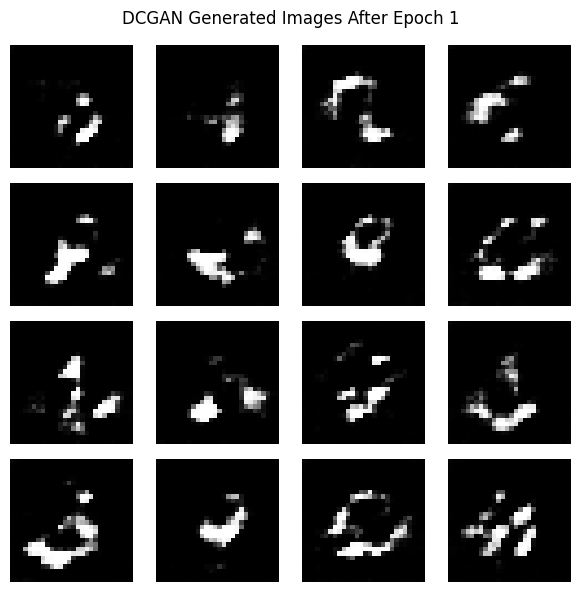

Epoch 02/10 | Generator Loss: 0.7765 | Discriminator Loss: 1.3102
Epoch 03/10 | Generator Loss: 0.8137 | Discriminator Loss: 1.2801
Epoch 04/10 | Generator Loss: 0.7736 | Discriminator Loss: 1.3251
Epoch 05/10 | Generator Loss: 0.7618 | Discriminator Loss: 1.3303


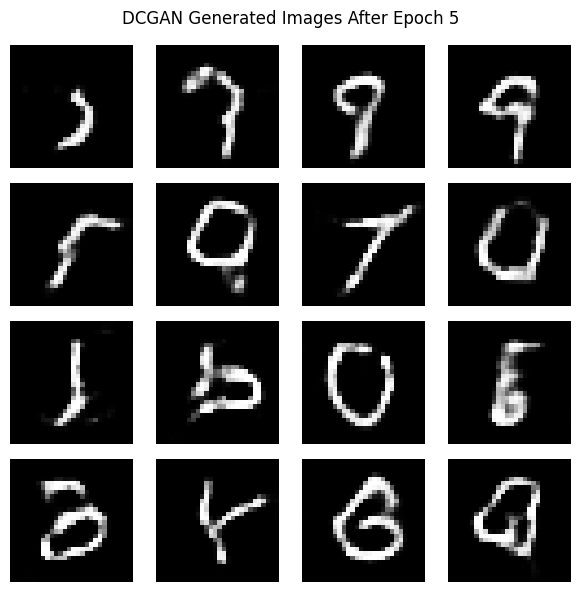

Epoch 06/10 | Generator Loss: 0.7664 | Discriminator Loss: 1.3238
Epoch 07/10 | Generator Loss: 0.7753 | Discriminator Loss: 1.3172
Epoch 08/10 | Generator Loss: 0.7858 | Discriminator Loss: 1.3077
Epoch 09/10 | Generator Loss: 0.7960 | Discriminator Loss: 1.2992
Epoch 10/10 | Generator Loss: 0.8034 | Discriminator Loss: 1.2977


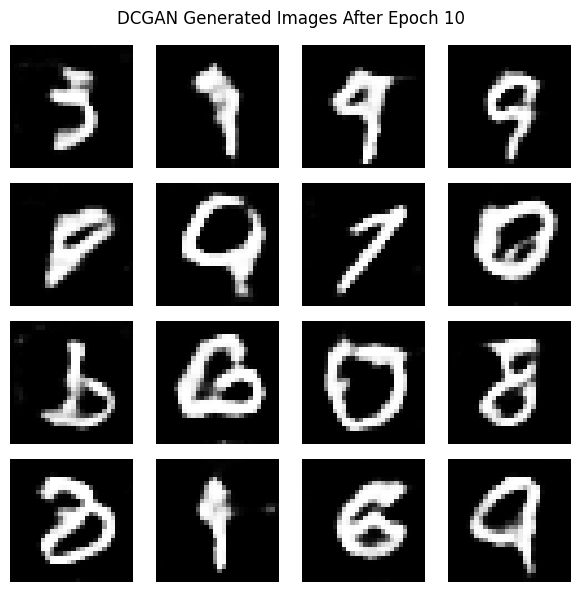

In [ ]:
def train(dataset, epochs):
    """Trains the DCGAN and displays generated images at selected epochs."""
    generator_losses = []
    discriminator_losses = []

    for epoch in range(1, epochs + 1):
        epoch_gen_losses = []
        epoch_disc_losses = []

        for image_batch in dataset:
            gen_loss, disc_loss = train_step(image_batch)
            epoch_gen_losses.append(gen_loss.numpy())
            epoch_disc_losses.append(disc_loss.numpy())

        avg_gen_loss = float(np.mean(epoch_gen_losses))
        avg_disc_loss = float(np.mean(epoch_disc_losses))
        generator_losses.append(avg_gen_loss)
        discriminator_losses.append(avg_disc_loss)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Generator Loss: {avg_gen_loss:.4f} | "
            f"Discriminator Loss: {avg_disc_loss:.4f}"
        )

        # Display images at the first epoch, every 5 epochs, and the final epoch.
        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            display_generated_images(generator, epoch, seed_noise)

    return generator_losses, discriminator_losses


generator_losses, discriminator_losses = train(train_dataset, EPOCHS)

## 11. Plot Training Losses

GAN loss curves may fluctuate because both networks are learning at the same time. Use these curves as a training monitor, not as the only quality measure.

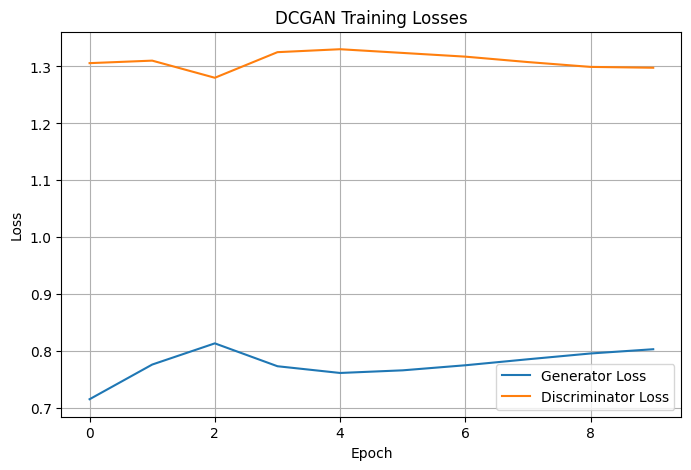

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(generator_losses, label="Generator Loss")
plt.plot(discriminator_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DCGAN Training Losses")
plt.legend()
plt.grid(True)
plt.show()

## 12. Generate Final Synthetic Images

The trained Generator can create new handwritten digit images from fresh random noise.

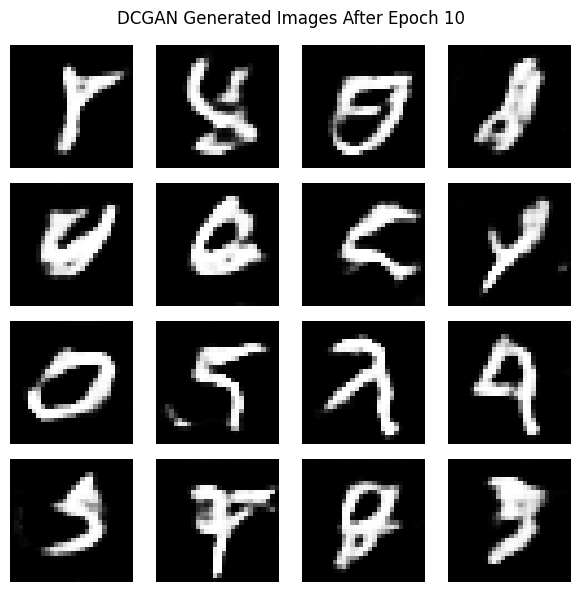

In [ ]:
# Generate new random noise vectors.
new_noise = tf.random.normal([NUM_EXAMPLES_TO_GENERATE, LATENT_DIM])

# Display final generated images.
display_generated_images(generator, EPOCHS, new_noise)

## Conclusion

This notebook implemented a Deep Convolutional GAN for generating handwritten digit images from the MNIST dataset. The Generator used transposed convolution layers to upsample random noise into images, and the Discriminator used convolution layers to classify images as real or generated.

Compared with a dense Vanilla GAN, DCGAN is better aligned with image data because it preserves and learns spatial structure. This makes it a foundational GAN architecture for image generation tasks.

The same approach can be extended to larger image datasets by increasing model capacity, training for more epochs, and using higher-resolution convolutional architectures.